Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [2]:
results_with = pd.read_csv('./final_with_reviewer.csv')
results_without = pd.read_csv('./final_without_reviewer.csv')

print(f"With reviewer:    {results_with['passed'].mean()*100:.1f}% accuracy, "
      f"{results_with['reviewed'].sum()} queries fixed")
print(f"Without reviewer: {results_without['passed'].mean()*100:.1f}% accuracy, "
      f"{results_without['reviewed'].sum()} queries fixed")

With reviewer:    100.0% accuracy, 3 queries fixed
Without reviewer: 100.0% accuracy, 0 queries fixed


Visualization

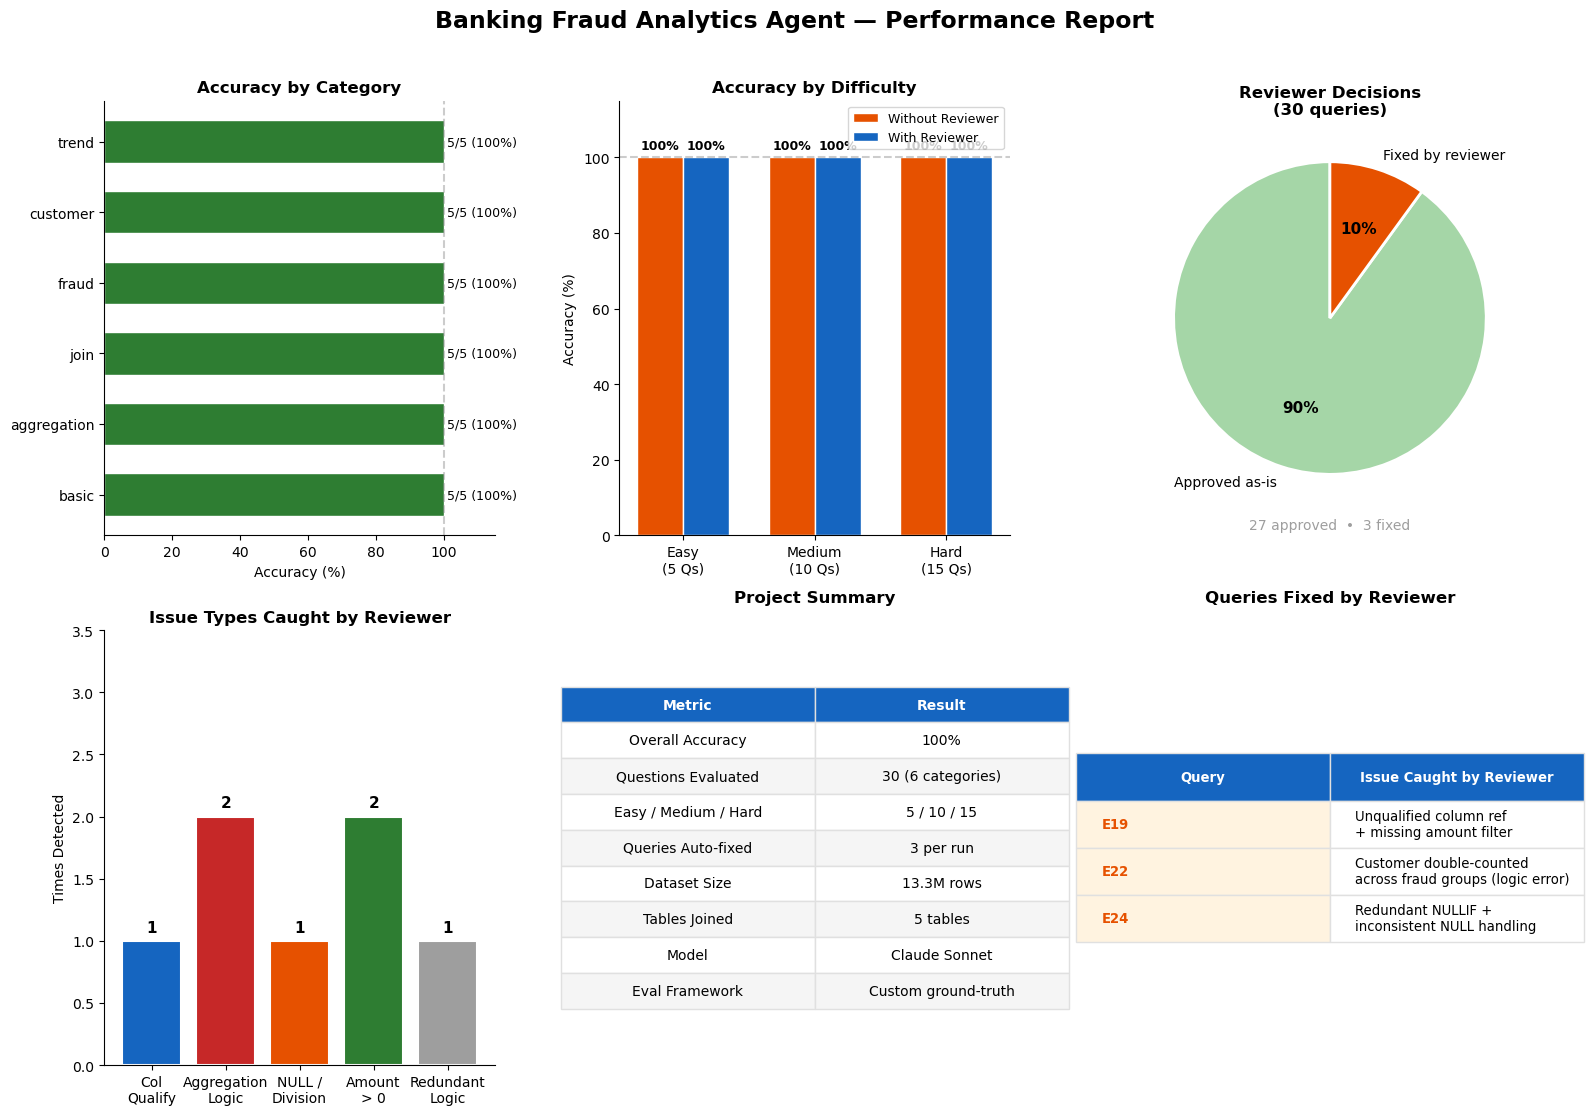

✓ Saved to eval_visualization.png


In [6]:
fig = plt.figure(figsize=(16, 11))
fig.suptitle('Banking Fraud Analytics Agent — Performance Report',
             fontsize=17, fontweight='bold', y=1.01)

C_BLUE    = '#1565C0'
C_LBLUE   = '#90CAF9'
C_GREEN   = '#2E7D32'
C_LGREEN  = '#A5D6A7'
C_ORANGE  = '#E65100'
C_RED     = '#C62828'
C_GRAY    = '#9E9E9E'

# ── Chart 1 (top-left): Accuracy by Category ─────────────────
ax1 = fig.add_subplot(2, 3, 1)

categories = ['basic', 'aggregation', 'join', 'fraud', 'customer', 'trend']
acc = [results_with[results_with['category']==c]['passed'].mean()*100
       for c in categories]
bar_colors = [C_GREEN if a == 100 else C_ORANGE for a in acc]

bars = ax1.barh(categories, acc, color=bar_colors, edgecolor='white', height=0.6)
ax1.set_xlim(0, 115)
ax1.set_xlabel('Accuracy (%)')
ax1.set_title('Accuracy by Category', fontweight='bold')
ax1.axvline(x=100, color='gray', linestyle='--', alpha=0.4)

total_per_cat = 5
for bar, a in zip(bars, acc):
    p = int(a / 100 * total_per_cat)
    ax1.text(a + 1, bar.get_y() + bar.get_height()/2,
             f'{p}/{total_per_cat} ({a:.0f}%)', va='center', fontsize=9)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2 (top-center): Accuracy by Difficulty ─────────────
ax2 = fig.add_subplot(2, 3, 2)

difficulties = ['easy', 'medium', 'hard']
diff_total = {'easy': 5, 'medium': 10, 'hard': 15}

with_acc    = [results_with[results_with['difficulty']==d]['passed'].mean()*100
               for d in difficulties]
without_acc = [results_without[results_without['difficulty']==d]['passed'].mean()*100
               for d in difficulties]

x = np.arange(len(difficulties))
w = 0.35
bars1 = ax2.bar(x - w/2, without_acc, w, label='Without Reviewer',
                color=C_ORANGE, edgecolor='white')
bars2 = ax2.bar(x + w/2, with_acc,    w, label='With Reviewer',
                color=C_BLUE,   edgecolor='white')

ax2.set_ylim(0, 115)
ax2.set_xticks(x)
ax2.set_xticklabels([f'{d.capitalize()}\n({diff_total[d]} Qs)' for d in difficulties])
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy by Difficulty', fontweight='bold')
ax2.axhline(y=100, color='gray', linestyle='--', alpha=0.4)
ax2.legend(fontsize=9)

for bar in list(bars1) + list(bars2):
    v = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, v + 1.5,
             f'{v:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Chart 3 (top-right): Reviewer Decision Pie ───────────────
ax3 = fig.add_subplot(2, 3, 3)

fixed_count    = int(results_with['reviewed'].sum())
approved_count = len(results_with) - fixed_count

wedges, texts, autotexts = ax3.pie(
    [approved_count, fixed_count],
    labels=['Approved as-is', 'Fixed by reviewer'],
    colors=[C_LGREEN, C_ORANGE],
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')

ax3.set_title('Reviewer Decisions\n(30 queries)', fontweight='bold')
ax3.text(0, -1.35, f'{approved_count} approved  •  {fixed_count} fixed',
         ha='center', fontsize=10, color=C_GRAY)

# ── Chart 4 (bottom-left): Issue Types Caught ────────────────
ax4 = fig.add_subplot(2, 3, 4)

# Intrepret issue type from Real Data
fixed_rows = results_with[results_with['reviewed'] == True]

issue_categories = {
    'Col\nQualify':     0,
    'Aggregation\nLogic': 0,
    'NULL /\nDivision': 0,
    'Amount\n> 0':      0,
    'Redundant\nLogic': 0,
}

for _, row in fixed_rows.iterrows():
    t = row['issues'].lower()
    if 'ambiguous' in t or 'qualified' in t or 'column' in t:
        issue_categories['Col\nQualify'] += 1
    if 'logic error' in t or 'weighted' in t or 'counted' in t or 'bias' in t:
        issue_categories['Aggregation\nLogic'] += 1
    if 'null' in t or 'division' in t or 'nullif' in t:
        issue_categories['NULL /\nDivision'] += 1
    if 'amount' in t and ('filter' in t or 'refund' in t or '> 0' in t):
        issue_categories['Amount\n> 0'] += 1
    if 'redundant' in t or 'unnecessary' in t or 'inconsistent' in t:
        issue_categories['Redundant\nLogic'] += 1

labels = list(issue_categories.keys())
vals   = list(issue_categories.values())
colors4 = [C_BLUE, C_RED, C_ORANGE, C_GREEN, C_GRAY]

bars4 = ax4.bar(labels, vals, color=colors4, edgecolor='white', linewidth=1.5)
ax4.set_ylabel('Times Detected')
ax4.set_title('Issue Types Caught by Reviewer', fontweight='bold')
ax4.set_ylim(0, max(vals) + 1.5)

for bar, v in zip(bars4, vals):
    if v > 0:
        ax4.text(bar.get_x() + bar.get_width()/2, v + 0.05,
                 str(v), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ── Chart 5 (bottom-center): Project Summary Table ───────────
ax5 = fig.add_subplot(2, 3, 5)
ax5.axis('off')

summary = [
    ['Metric',               'Result'],
    ['Overall Accuracy',     '100%'],
    ['Questions Evaluated',  '30 (6 categories)'],
    ['Easy / Medium / Hard', '5 / 10 / 15'],
    ['Queries Auto-fixed',   f'{fixed_count} per run'],
    ['Dataset Size',         '13.3M rows'],
    ['Tables Joined',        '5 tables'],
    ['Model',                'Claude Sonnet'],
    ['Eval Framework',       'Custom ground-truth'],
]

table = ax5.table(cellText=summary[1:], colLabels=summary[0],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 1.9)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(C_BLUE)
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F5F5F5')
    else:
        cell.set_facecolor('white')
    cell.set_edgecolor('#E0E0E0')

ax5.set_title('Project Summary', fontweight='bold', pad=20)

# ── Chart 6 (bottom-right): Fixed Query Details ──────────────
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')

short_issues = {
    'E19': 'Unqualified column ref\n+ missing amount filter',
    'E22': 'Customer double-counted\nacross fraud groups (logic error)',
    'E24': 'Redundant NULLIF +\ninconsistent NULL handling',
}

fixed_data = [['Query', 'Issue Caught by Reviewer']]
for qid, issue in short_issues.items():
    fixed_data.append([qid, issue])

table2 = ax6.table(cellText=fixed_data[1:], colLabels=fixed_data[0],
                   loc='center', cellLoc='left')
table2.auto_set_font_size(False)
table2.set_fontsize(9.5)
table2.scale(1.3, 2.5)

for (row, col), cell in table2.get_celld().items():
    if row == 0:
        cell.set_facecolor(C_BLUE)
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 0:
        cell.set_facecolor('#FFF3E0')
        cell.set_text_props(fontweight='bold', color=C_ORANGE)
    else:
        cell.set_facecolor('white')
    cell.set_edgecolor('#E0E0E0')

ax6.set_title('Queries Fixed by Reviewer', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('./eval_visualization.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✓ Saved to eval_visualization.png")